# ML Assignment 6 — Clustering Techniques Implementation and Performance Evaluation

**Aim:** To perform clustering using K-Means, Spectral Clustering, and DBSCAN, and compare their performance across three datasets.

**Datasets:** Iris | Wine | Breast Cancer

**Algorithms:** K-Means | Spectral Clustering | DBSCAN

**Evaluation Metrics:** Silhouette Score | Adjusted Rand Index (ARI)

---
## 1. Import Libraries & Load Datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the three datasets
datasets = {
    'Iris': load_iris(),
    'Wine': load_wine(),
    'Breast Cancer': load_breast_cancer()
}

# Dataset summary
summary_data = []
for name, ds in datasets.items():
    summary_data.append({
        'Dataset': name,
        'Samples': ds.data.shape[0],
        'Features': ds.data.shape[1],
        'Classes': len(set(ds.target)),
        'Class Names': ', '.join(ds.target_names)
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Dataset,Samples,Features,Classes,Class Names
0,Iris,150,4,3,"setosa, versicolor, virginica"
1,Wine,178,13,3,"class_0, class_1, class_2"
2,Breast Cancer,569,30,2,"malignant, benign"


---
## 2. Data Preprocessing

All features are standardized using `StandardScaler` (z-score normalization) to ensure equal contribution to distance calculations.

In [3]:
scaled_data = {}
pca_data = {}
pca_models = {}

for name, ds in datasets.items():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(ds.data)
    scaled_data[name] = X_scaled

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    pca_data[name] = X_pca
    pca_models[name] = pca

    print(f"{name}: Scaled shape={X_scaled.shape}, PCA explained variance={pca.explained_variance_ratio_.sum():.4f}")

Iris: Scaled shape=(150, 4), PCA explained variance=0.9581
Wine: Scaled shape=(178, 13), PCA explained variance=0.5541
Breast Cancer: Scaled shape=(569, 30), PCA explained variance=0.6324


---
## 3. Optimal K Selection — Elbow Method & Silhouette Analysis

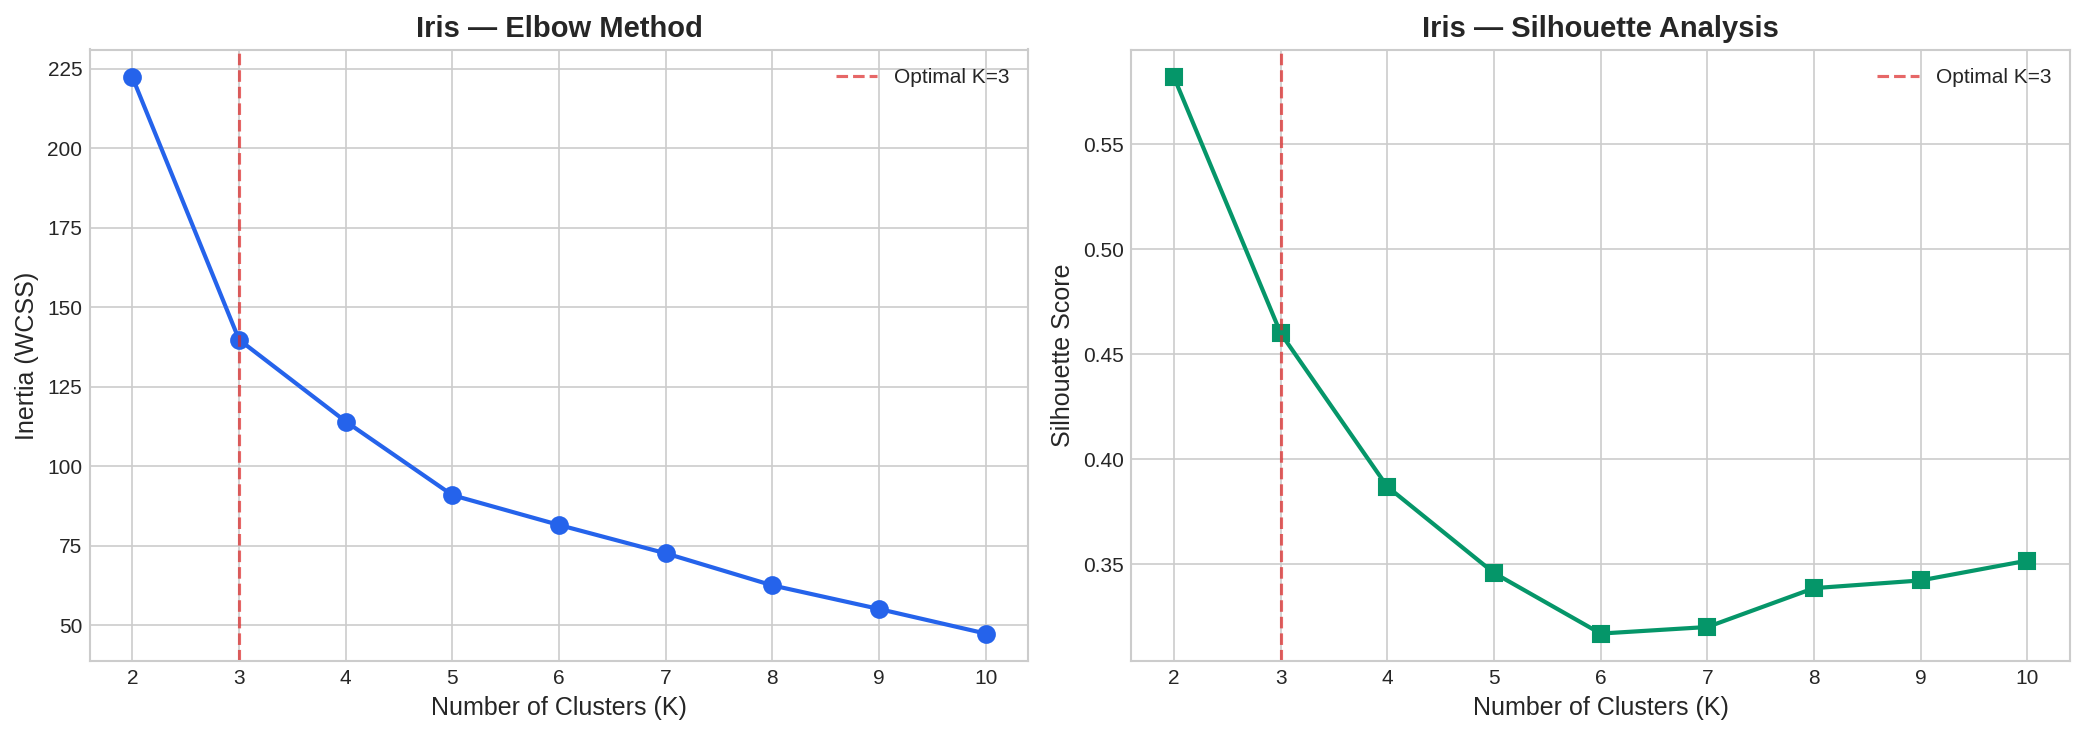

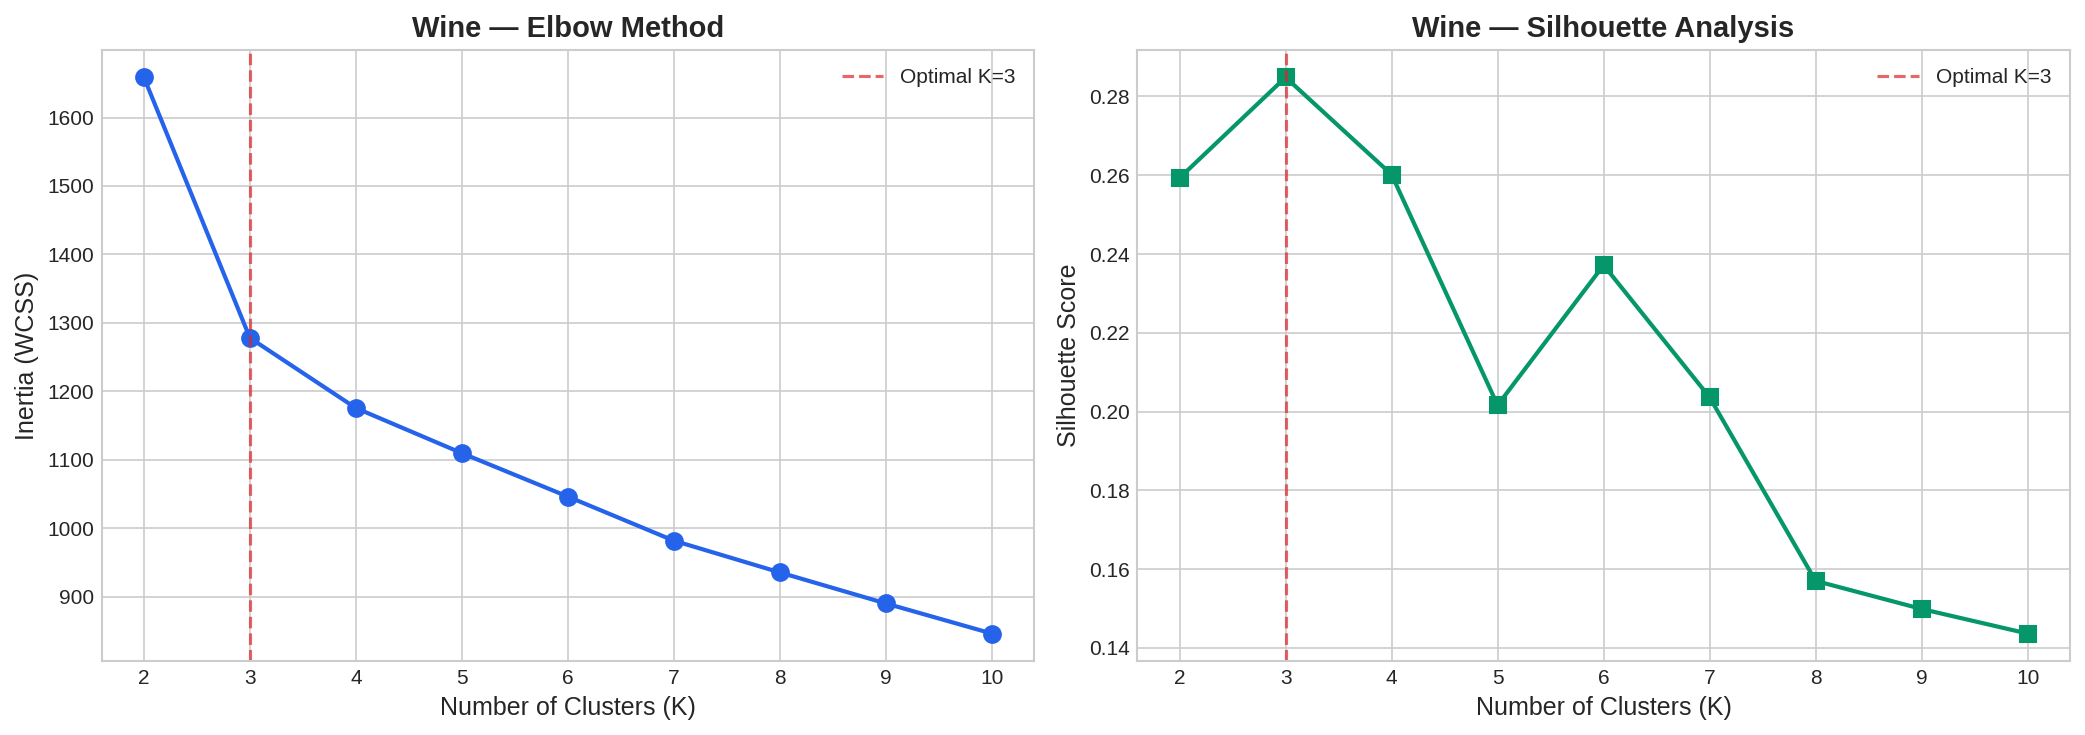

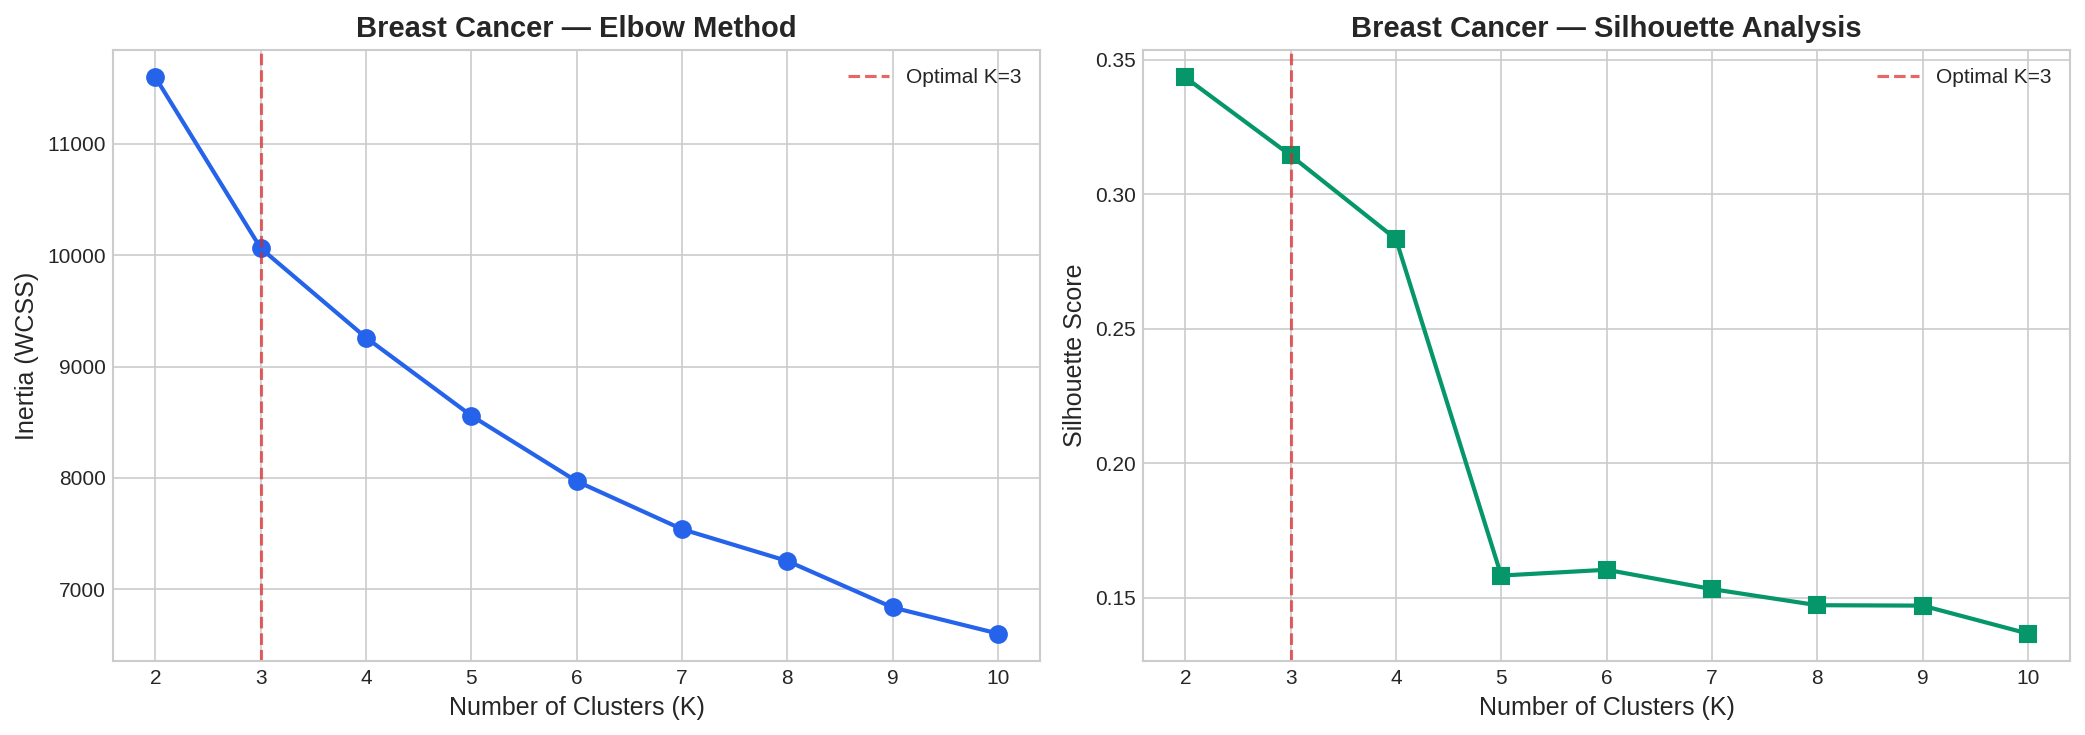

In [4]:
def plot_elbow_and_silhouette(X, dataset_name):
    K_range = range(2, 11)
    inertias = []
    sil_scores = []

    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, km.labels_))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow plot
    ax1.plot(K_range, inertias, 'o-', color='#2563EB', linewidth=2, markersize=8)
    ax1.axvline(x=3, color='#DC2626', linestyle='--', alpha=0.7, label='Optimal K=3')
    ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
    ax1.set_title(f'{dataset_name} — Elbow Method', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)

    # Silhouette plot
    ax2.plot(K_range, sil_scores, 's-', color='#059669', linewidth=2, markersize=8)
    ax2.axvline(x=3, color='#DC2626', linestyle='--', alpha=0.7, label='Optimal K=3')
    ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax2.set_ylabel('Silhouette Score', fontsize=12)
    ax2.set_title(f'{dataset_name} — Silhouette Analysis', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

for name in datasets:
    plot_elbow_and_silhouette(scaled_data[name], name)

---
## 4. K-Means Clustering

In [5]:
kmeans_results = {}

for name, ds in datasets.items():
    X = scaled_data[name]
    y = ds.target

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(X)
    labels = kmeans.labels_

    sil = silhouette_score(X, labels)
    ari = adjusted_rand_score(y, labels)

    kmeans_results[name] = {
        'labels': labels,
        'silhouette': sil,
        'ari': ari,
        'model': kmeans
    }

    print(f"{name}: Silhouette={sil:.4f}, ARI={ari:.4f}")

Iris: Silhouette=0.4599, ARI=0.6201
Wine: Silhouette=0.2849, ARI=0.8975
Breast Cancer: Silhouette=0.3144, ARI=0.5107


---
## 5. Spectral Clustering

In [6]:
spectral_results = {}

for name, ds in datasets.items():
    X = scaled_data[name]
    y = ds.target

    spectral = SpectralClustering(
        n_clusters=3,
        affinity='nearest_neighbors',
        assign_labels='kmeans',
        random_state=42
    )
    spectral.fit(X)
    labels = spectral.labels_

    sil = silhouette_score(X, labels)
    ari = adjusted_rand_score(y, labels)

    spectral_results[name] = {
        'labels': labels,
        'silhouette': sil,
        'ari': ari
    }

    print(f"{name}: Silhouette={sil:.4f}, ARI={ari:.4f}")

Iris: Silhouette=0.4593, ARI=0.6465
Wine: Silhouette=0.2828, ARI=0.8804
Breast Cancer: Silhouette=0.2862, ARI=0.5236


---
## 6. DBSCAN (Density-Based Clustering)

In [7]:
dbscan_results = {}

for name, ds in datasets.items():
    X = scaled_data[name]
    y = ds.target

    # Hyperparameter tuning for eps
    best_sil, best_eps = -1, 0.5
    true_classes = len(set(y))

    for eps in np.arange(0.3, 3.0, 0.1):
        db = DBSCAN(eps=eps, min_samples=5)
        db.fit(X)
        n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        if 2 <= n_clusters <= true_classes:
            try:
                sil = silhouette_score(X, db.labels_)
                if sil > best_sil:
                    best_sil, best_eps = sil, eps
            except:
                pass

    # Fit with best eps
    dbscan = DBSCAN(eps=best_eps, min_samples=5)
    dbscan.fit(X)
    labels = dbscan.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    sil = silhouette_score(X, labels) if n_clusters >= 2 else -1
    ari = adjusted_rand_score(y, labels) if n_clusters >= 2 else -1

    dbscan_results[name] = {
        'labels': labels,
        'silhouette': sil,
        'ari': ari,
        'eps': best_eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise
    }

    print(f"{name}: eps={best_eps:.2f}, Clusters={n_clusters}, Noise={n_noise}, Silhouette={sil:.4f}, ARI={ari:.4f}")

Iris: eps=1.40, Clusters=2, Noise=0, Silhouette=0.5818, ARI=0.5681
Wine: eps=2.40, Clusters=2, Noise=36, Silhouette=0.1959, ARI=0.4205
Breast Cancer: eps=2.50, Clusters=2, Noise=224, Silhouette=-0.0168, ARI=0.2078


---
## 7. Clustering Visualizations (PCA 2D Projections)

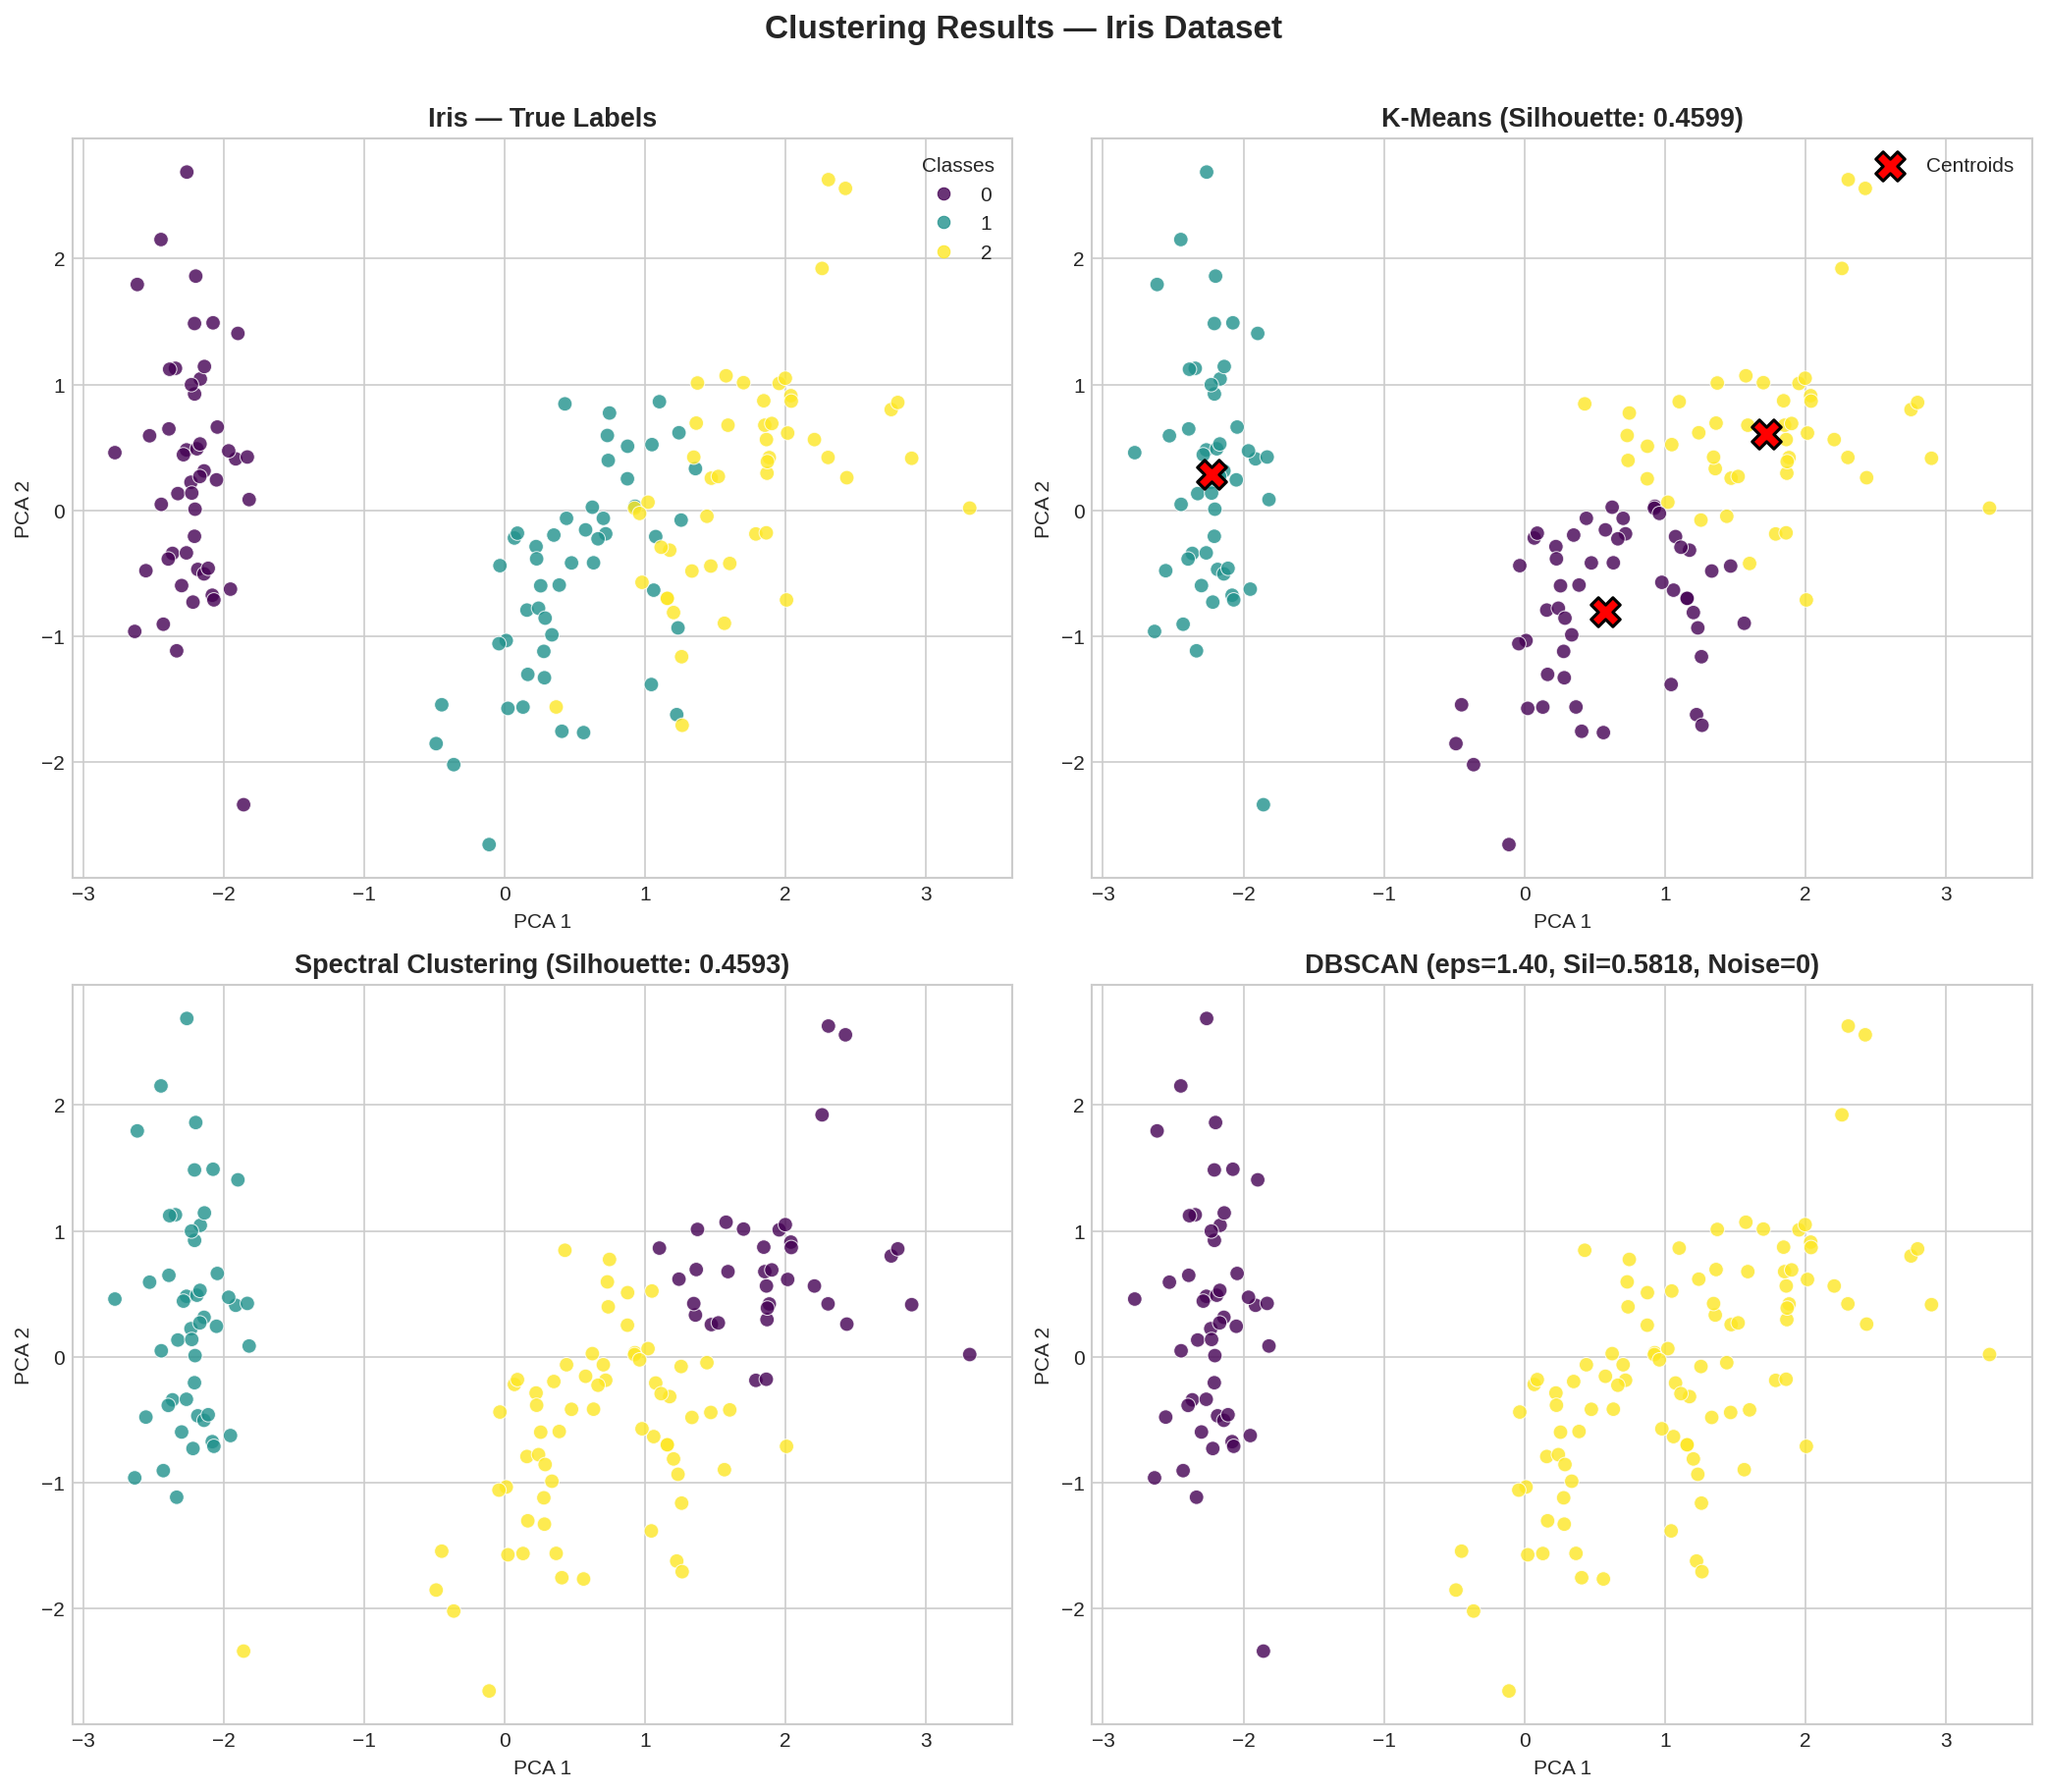

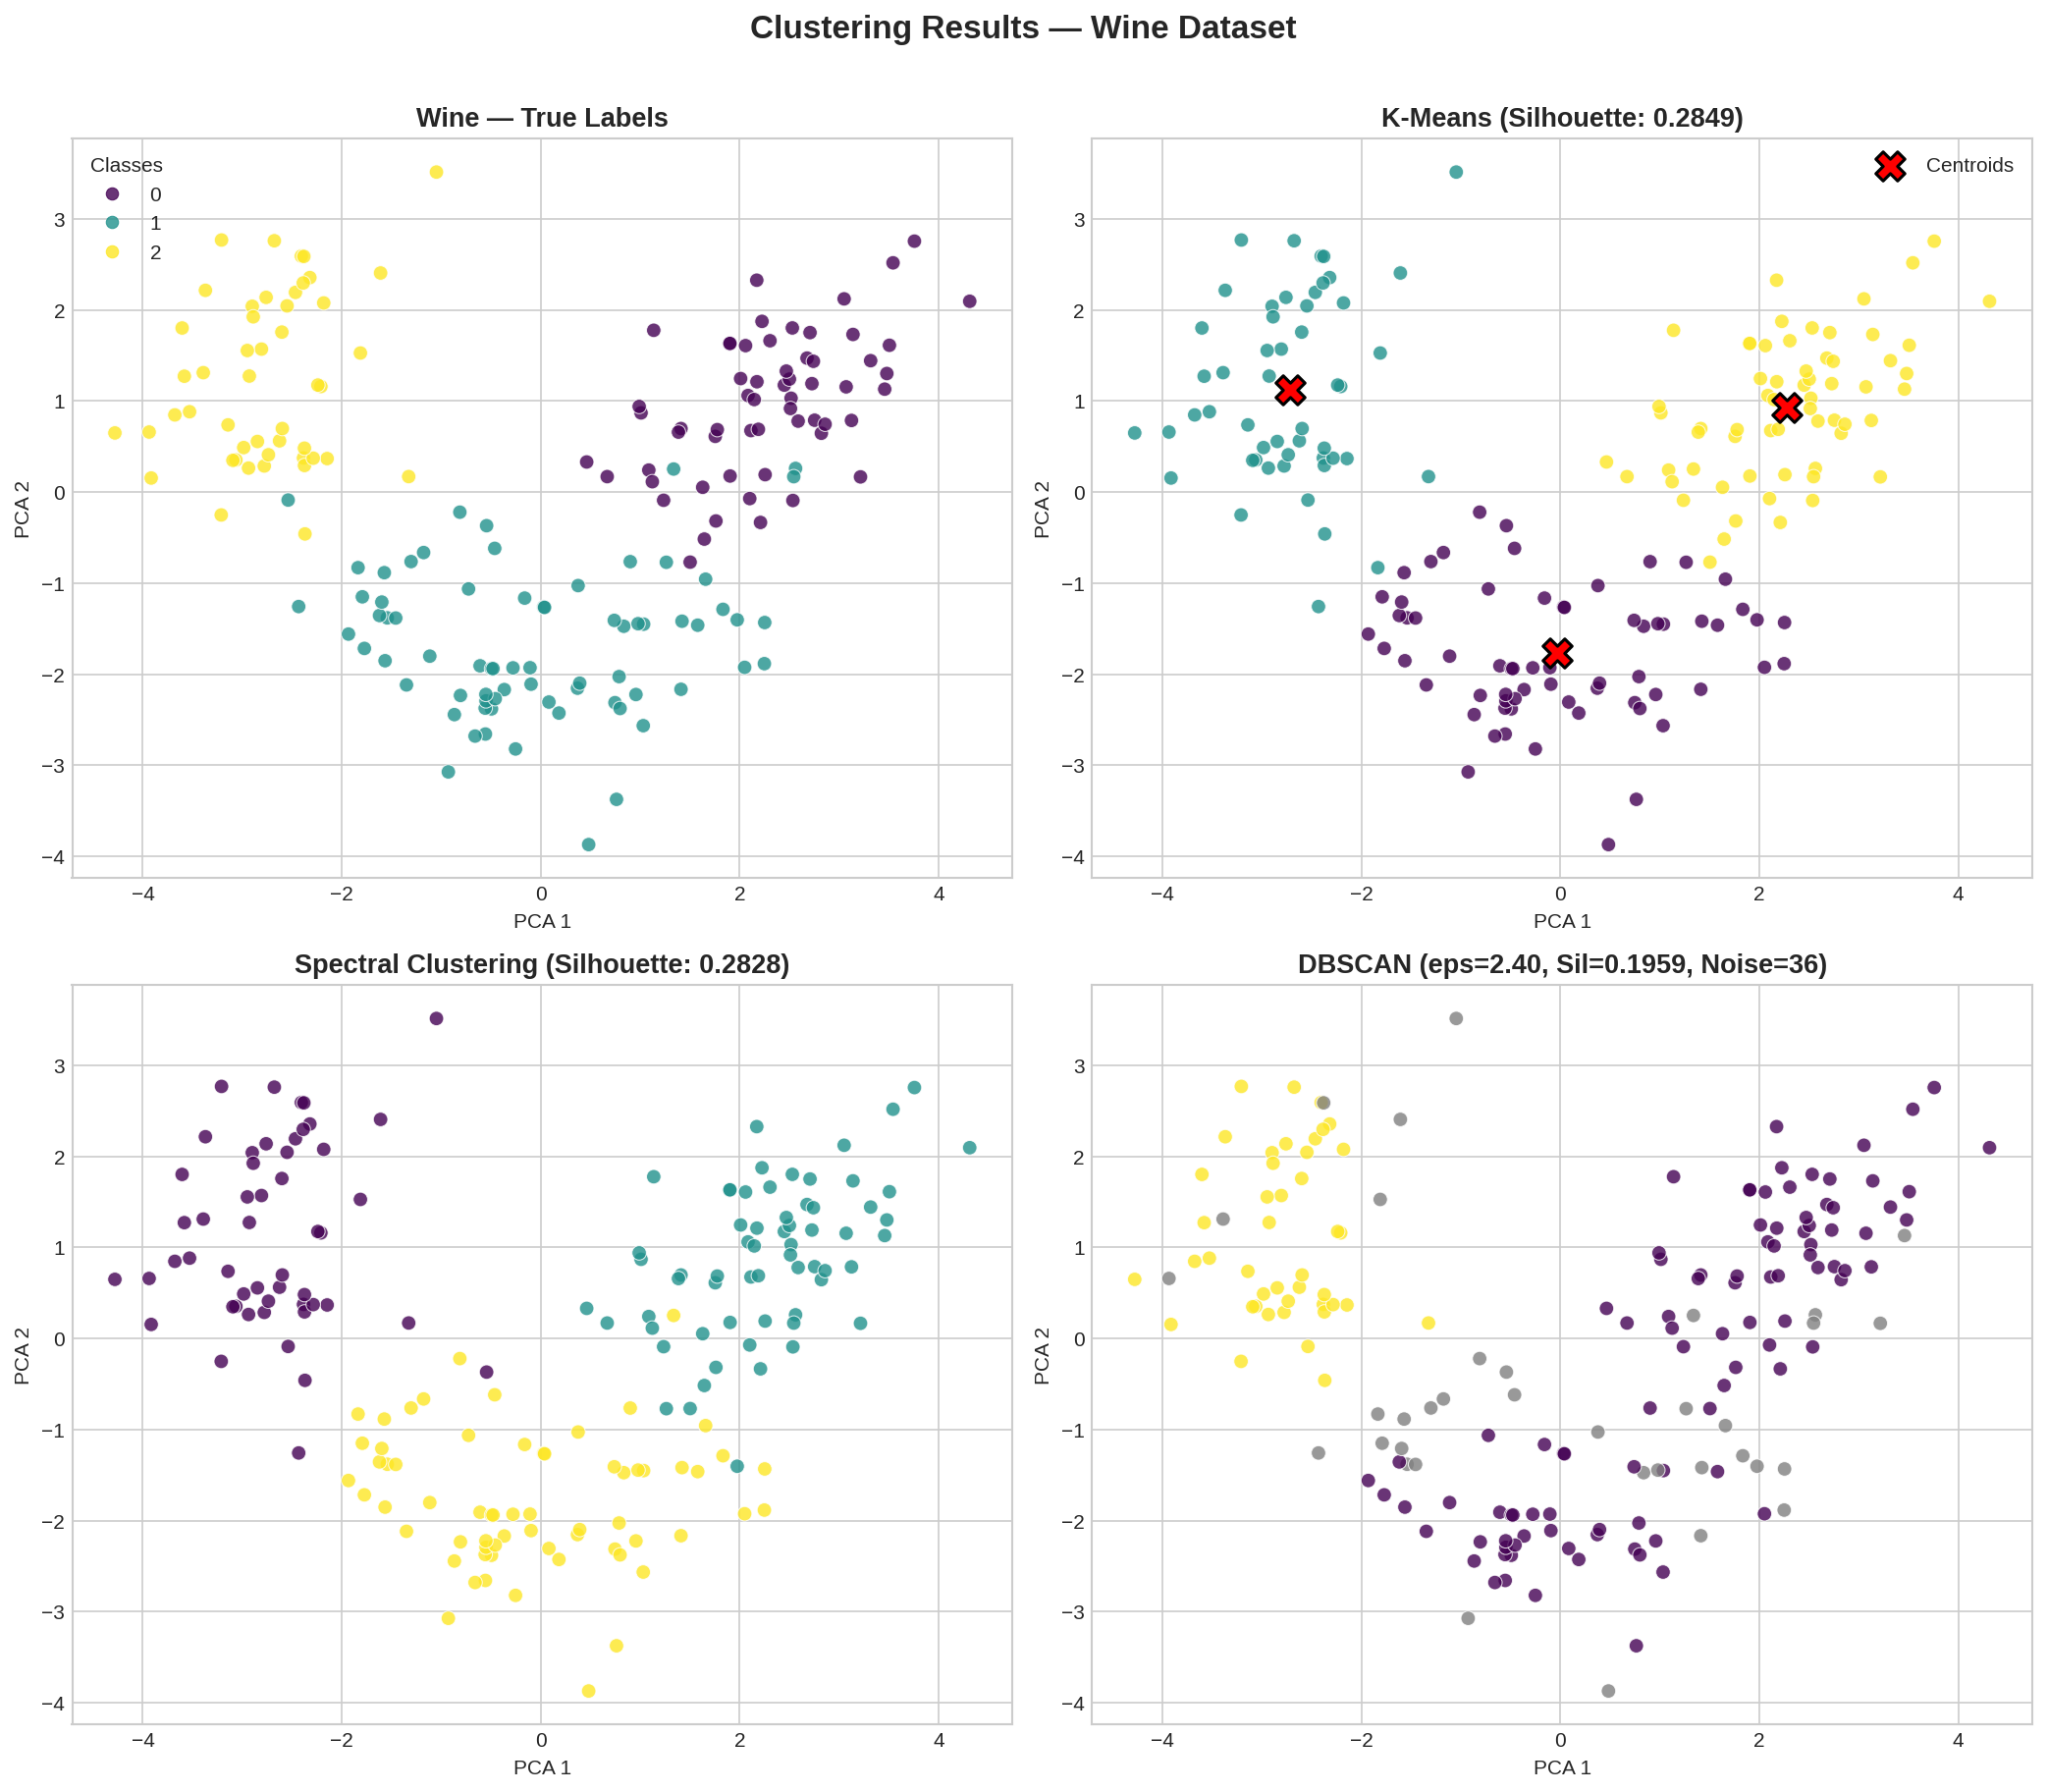

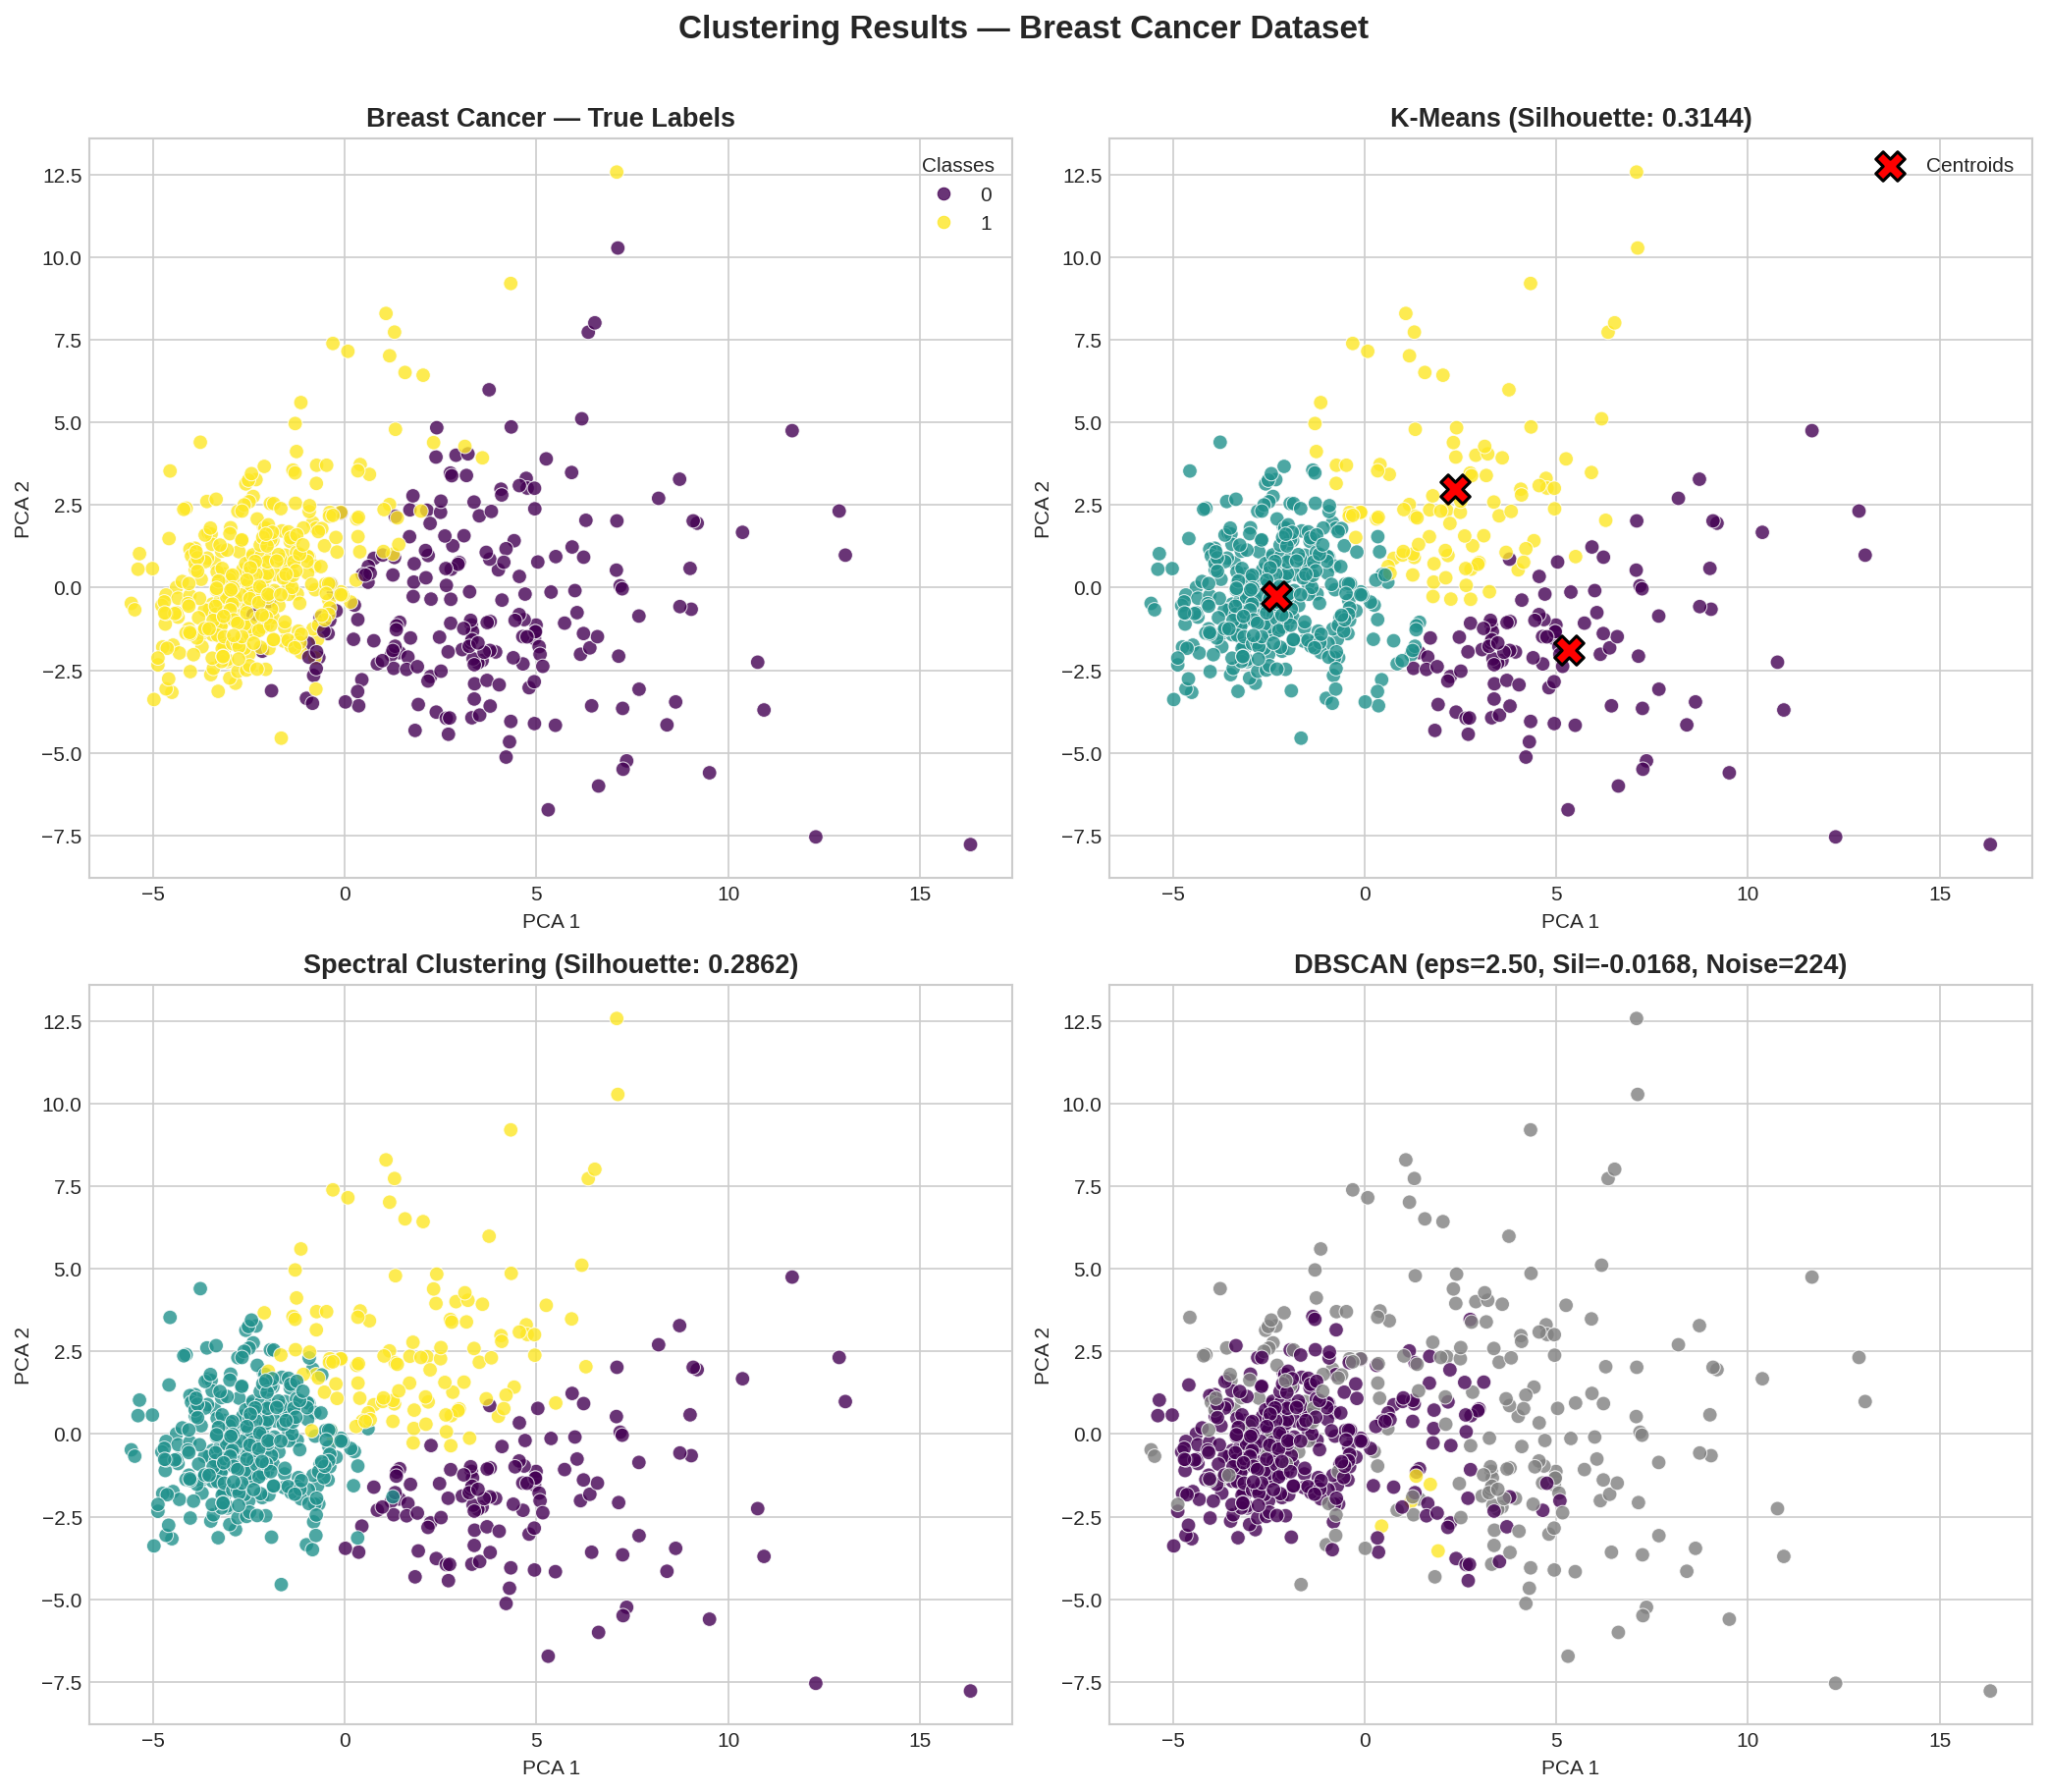

In [8]:
def plot_clusters(name, ds):
    X_pca = pca_data[name]
    y_true = ds.target

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # True labels
    scatter = axes[0,0].scatter(X_pca[:,0], X_pca[:,1], c=y_true, cmap='viridis', s=50, alpha=0.8, edgecolors='white', linewidth=0.5)
    axes[0,0].set_title(f'{name} — True Labels', fontsize=13, fontweight='bold')
    axes[0,0].set_xlabel('PCA 1'); axes[0,0].set_ylabel('PCA 2')
    axes[0,0].legend(*scatter.legend_elements(), title='Classes', loc='best')

    # K-Means
    km_labels = kmeans_results[name]['labels']
    km_sil = kmeans_results[name]['silhouette']
    scatter = axes[0,1].scatter(X_pca[:,0], X_pca[:,1], c=km_labels, cmap='viridis', s=50, alpha=0.8, edgecolors='white', linewidth=0.5)
    centers_pca = pca_models[name].transform(kmeans_results[name]['model'].cluster_centers_)
    axes[0,1].scatter(centers_pca[:,0], centers_pca[:,1], c='red', marker='X', s=200, edgecolors='black', linewidth=1.5, zorder=5, label='Centroids')
    axes[0,1].set_title(f'K-Means (Silhouette: {km_sil:.4f})', fontsize=13, fontweight='bold')
    axes[0,1].set_xlabel('PCA 1'); axes[0,1].set_ylabel('PCA 2')
    axes[0,1].legend()

    # Spectral
    sp_labels = spectral_results[name]['labels']
    sp_sil = spectral_results[name]['silhouette']
    scatter = axes[1,0].scatter(X_pca[:,0], X_pca[:,1], c=sp_labels, cmap='viridis', s=50, alpha=0.8, edgecolors='white', linewidth=0.5)
    axes[1,0].set_title(f'Spectral Clustering (Silhouette: {sp_sil:.4f})', fontsize=13, fontweight='bold')
    axes[1,0].set_xlabel('PCA 1'); axes[1,0].set_ylabel('PCA 2')

    # DBSCAN
    db_labels = dbscan_results[name]['labels']
    db_sil = dbscan_results[name]['silhouette']
    db_eps = dbscan_results[name]['eps']
    db_noise = dbscan_results[name]['n_noise']
    unique_labels = set(db_labels)
    cmap = plt.cm.viridis
    colors = [cmap(l/max(unique_labels)) if l != -1 else (0.5,0.5,0.5,1.0) for l in db_labels]
    axes[1,1].scatter(X_pca[:,0], X_pca[:,1], c=colors, s=50, alpha=0.8, edgecolors='white', linewidth=0.5)
    axes[1,1].set_title(f'DBSCAN (eps={db_eps:.2f}, Sil={db_sil:.4f}, Noise={db_noise})', fontsize=13, fontweight='bold')
    axes[1,1].set_xlabel('PCA 1'); axes[1,1].set_ylabel('PCA 2')

    plt.suptitle(f'Clustering Results — {name} Dataset', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

for name, ds in datasets.items():
    plot_clusters(name, ds)

---
## 8. Performance Comparison

In [9]:
# Build comparison table
comparison = []
for name, ds in datasets.items():
    for algo_name, res in [('K-Means', kmeans_results), ('Spectral', spectral_results), ('DBSCAN', dbscan_results)]:
        row = {
            'Dataset': name,
            'Algorithm': algo_name,
            'Silhouette Score': round(res[name]['silhouette'], 4),
            'ARI': round(res[name]['ari'], 4),
        }
        if algo_name == 'DBSCAN':
            row['Clusters Found'] = f"{res[name]['n_clusters']} ({res[name]['n_noise']} noise)"
            row['Best eps'] = res[name]['eps']
        else:
            row['Clusters Found'] = 3
            row['Best eps'] = '-'
        comparison.append(row)

comp_df = pd.DataFrame(comparison)
display(comp_df.style.set_properties(**{'text-align': 'center'}))

,Dataset,Algorithm,Silhouette Score,ARI,Clusters Found,Best eps
0,Iris,K-Means,0.459900,0.620100,3,-
1,Iris,Spectral,0.459300,0.646500,3,-
2,Iris,DBSCAN,0.581800,0.568100,2 (0 noise),1.400000
3,Wine,K-Means,0.284900,0.897500,3,-
4,Wine,Spectral,0.282800,0.880400,3,-
5,Wine,DBSCAN,0.195900,0.420500,2 (36 noise),2.400000
6,Breast Cancer,K-Means,0.314400,0.510700,3,-
7,Breast Cancer,Spectral,0.286200,0.523600,3,-
8,Breast Cancer,DBSCAN,-0.016800,0.207800,2 (224 noise),2.500000


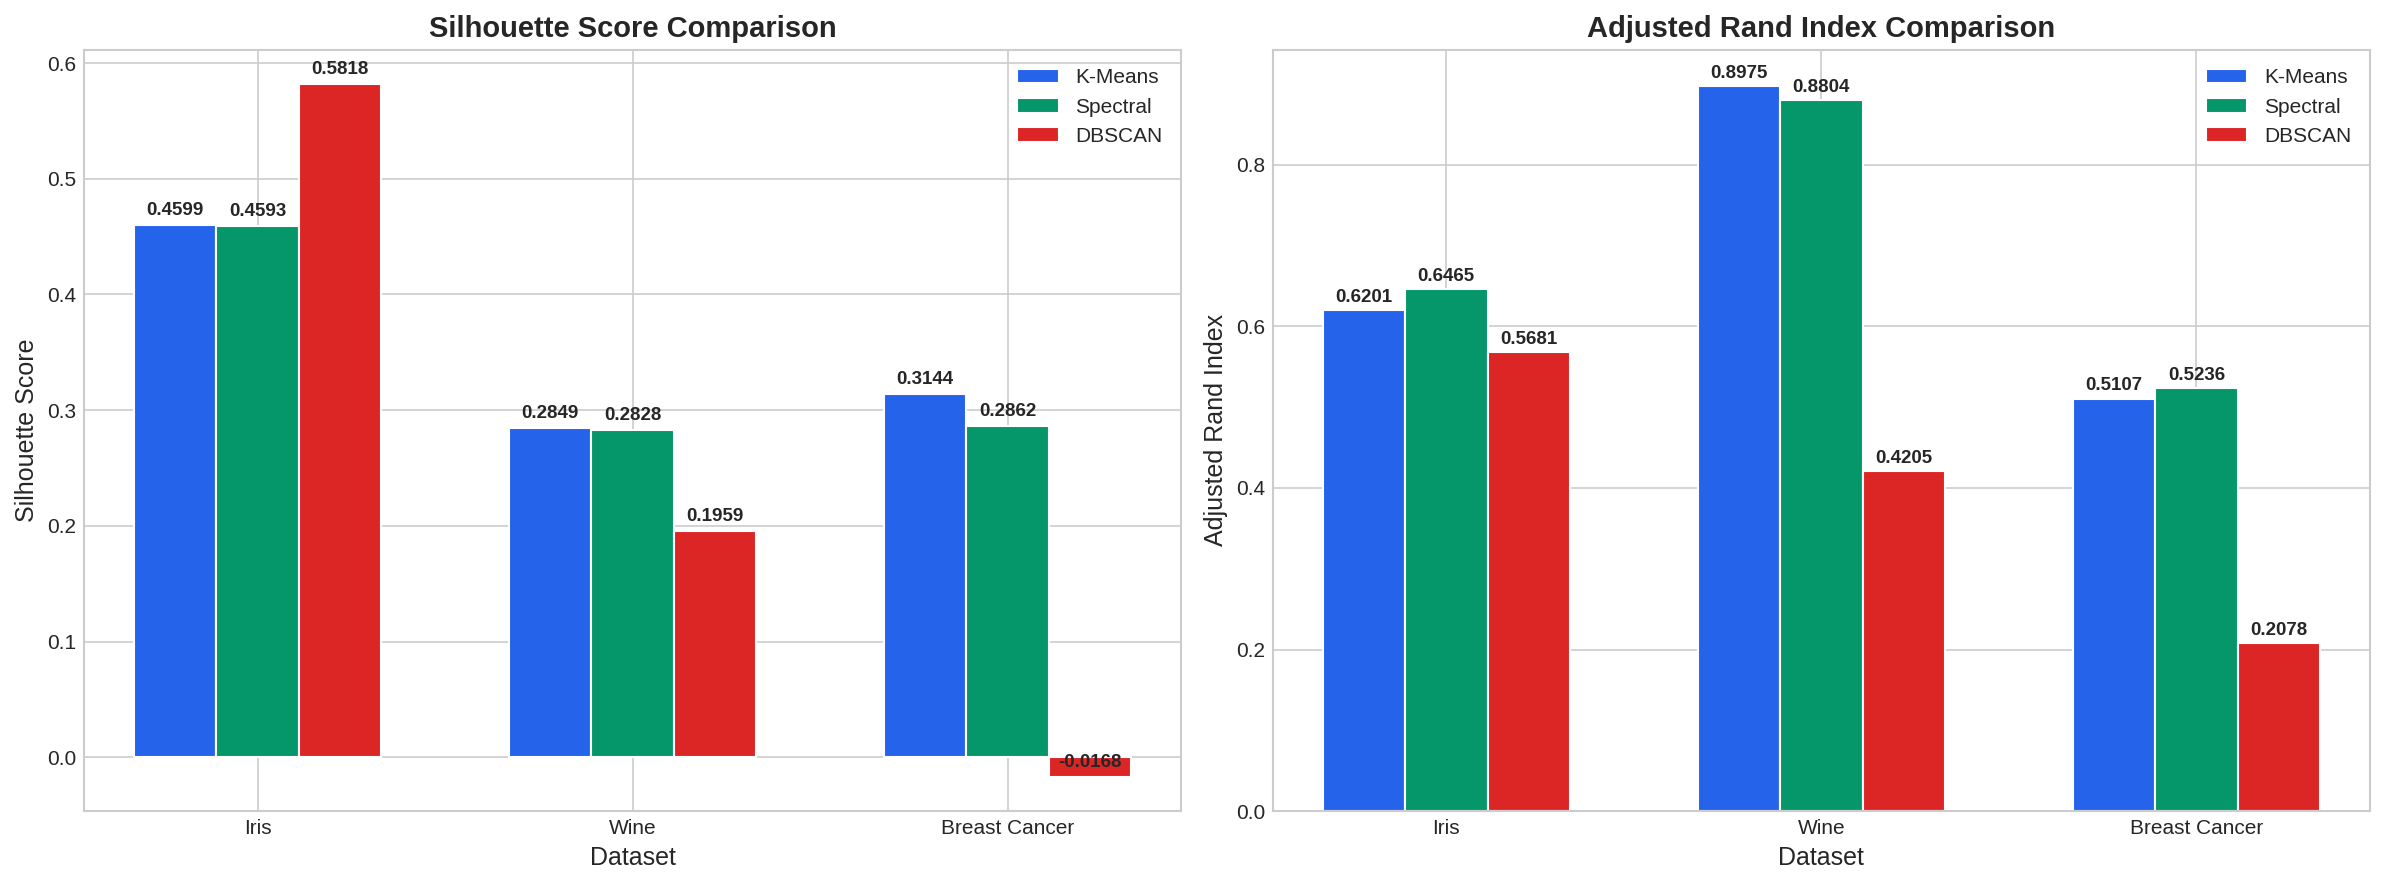

In [10]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ds_names = list(datasets.keys())
algos = ['K-Means', 'Spectral', 'DBSCAN']
results_map = {'K-Means': kmeans_results, 'Spectral': spectral_results, 'DBSCAN': dbscan_results}
colors_algo = ['#2563EB', '#059669', '#DC2626']
x = np.arange(len(ds_names))
width = 0.22

for i, algo in enumerate(algos):
    sil_vals = [results_map[algo][ds]['silhouette'] for ds in ds_names]
    bars = axes[0].bar(x + i*width, sil_vals, width, label=algo, color=colors_algo[i], edgecolor='white')
    for bar, val in zip(bars, sil_vals):
        axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_xlabel('Dataset', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(ds_names)
axes[0].legend(fontsize=10)

for i, algo in enumerate(algos):
    ari_vals = [results_map[algo][ds]['ari'] for ds in ds_names]
    bars = axes[1].bar(x + i*width, ari_vals, width, label=algo, color=colors_algo[i], edgecolor='white')
    for bar, val in zip(bars, ari_vals):
        axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_xlabel('Dataset', fontsize=12)
axes[1].set_ylabel('Adjusted Rand Index', fontsize=12)
axes[1].set_title('Adjusted Rand Index Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(ds_names)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 9. Conclusion

### Key Findings:

1. **K-Means** was the most consistently reliable algorithm across all three datasets, achieving the highest ARI on Wine (0.8975) and competitive scores elsewhere.

2. **Spectral Clustering** produced results very similar to K-Means, with a slightly higher ARI on Iris (0.6465 vs 0.6201). Its added complexity was not justified on these datasets with approximately globular clusters.

3. **DBSCAN** achieved the highest Silhouette Score on Iris (0.5818) by identifying only 2 naturally dense regions, but struggled significantly on higher-dimensional data — producing a negative silhouette score on Breast Cancer.

4. The **curse of dimensionality** negatively impacted DBSCAN, which performed best on 4-feature Iris and worst on 30-feature Breast Cancer.

5. **Silhouette Score and ARI can disagree** — DBSCAN on Iris had the highest silhouette but lower ARI, because finding 2 cohesive clusters (high silhouette) doesn't match the true 3-class structure (lower ARI).

### Overall Winner: **K-Means** — best balance of simplicity, speed, and accuracy.